In [1]:
import numpy as np
import pandas as pd
import os
from glob import glob
from tqdm import tqdm
from datetime import datetime

from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from astropy.io import fits
from matplotlib import pyplot as plt
from matplotlib import rc
import matplotlib
%matplotlib inline

from astropy.visualization import ZScaleInterval, hist
import astropy
import astropy.units as u
import astropy.stats
from astropy.modeling import fitting
from astropy.modeling.models import Polynomial1D, Chebyshev1D, Legendre1D, Hermite1D
from astropy.nddata import CCDData

from photutils.aperture import CircularAperture,CircularAnnulus
from photutils.aperture import aperture_photometry
from photutils.detection import DAOStarFinder
from photutils.aperture import ApertureStats
from astropy.table import Table

from ccdproc import ImageFileCollection
import ccdproc as ccdp

In [3]:
os.environ["PATH"] += os.pathsep + '/Library/TeX/texbin' # Adjust path as needed
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True
plt.rc('text',usetex=True)
plt.rc('font',**{'family':'serif','serif':['Computer Modern Roman'],'size':12})#,'weight':'bold'})
plt.rc('xtick',**{'labelsize':16})
plt.rc('ytick',**{'labelsize':16})
plt.rc('axes',**{'labelsize':18,'titlesize':20})

In [4]:
data_dir = '../Imaging/'
reduced_dir = '../Reduced/imgs_otzdf/'
data_fname = 'imgdata_hw6.csv'
df = pd.read_csv(data_fname)

df

,fn,fnum,objname,filter,trimsec,biassec,fn_otzdf
0,../Imaging/a001.fits,1,SERVICE,NaN,"[:53, 1:2048]","[54:2101, 1:2048]",../Reduced/a001_otzdf.fits
1,../Imaging/a002.fits,2,SERVICE,NaN,"[:53, 1:2048]","[54:2101, 1:2048]",../Reduced/a002_otzdf.fits
2,../Imaging/a003.fits,3,SERVICE,NaN,"[:53, 1:2048]","[54:2101, 1:2048]",../Reduced/a003_otzdf.fits
3,../Imaging/a004.fits,4,SERVICE,NaN,"[:53, 1:2048]","[54:2101, 1:2048]",../Reduced/a004_otzdf.fits
4,../Imaging/a005.fits,5,SERVICE,NaN,"[:53, 1:2048]","[54:2101, 1:2048]",../Reduced/a005_otzdf.fits
...,...,...,...,...,...,...,...
219,../Imaging/a242.fits,242,PG1633+099,V,"[:53, 1:2048]","[54:2101, 1:2048]",../Reduced/a242_otzdf.fits
220,../Imaging/a243.fits,243,PG1633+099,R,"[:53, 1:2048]","[54:2101, 1:2048]",../Reduced/a243_otzdf.fits
221,../Imaging/a244.fits,244,PG1633+099,R,"[:53, 1:2048]","[54:2101, 1:2048]",../Reduced/a244_otzdf.fits
222,../Imaging/a245.fits,245,PG1633+099,I,"[:53, 1:2048]","[54:2101, 1:2048]",../Reduced/a245_otzdf.fits


# 1) ADU vs. Exposure Time (CCD Linearity Test)
Note that linearity seems to hold when we look at 1) the entire frame's average count and 2) the ~10th percentile of the count distribution in a saturated region of the image. When we look at the straight average of a saturated region of the image, it doesn't seem that the counts rise linearly. I'm not sure why this is.

In [114]:
lintest_fns = np.sort(df['fn'][df['fnum'].between(74, 80)].values)

lintest_counts = []
lintest_sat_counts = []
lintest_sat_counts_10 = []
for fn in lintest_fns:
    dat = fits.open(fn)[0].data
    dat_sat = dat[1705:1715, 665:675] # Saturated range
    lintest_counts.append(np.average(dat))
    lintest_sat_counts.append(np.mean(dat_sat))
    lintest_sat_counts_10.append(np.percentile(dat_sat, 10))

Text(0.5, 1.0, 'ADU vs. Exp Time\n(Saturated Region)')

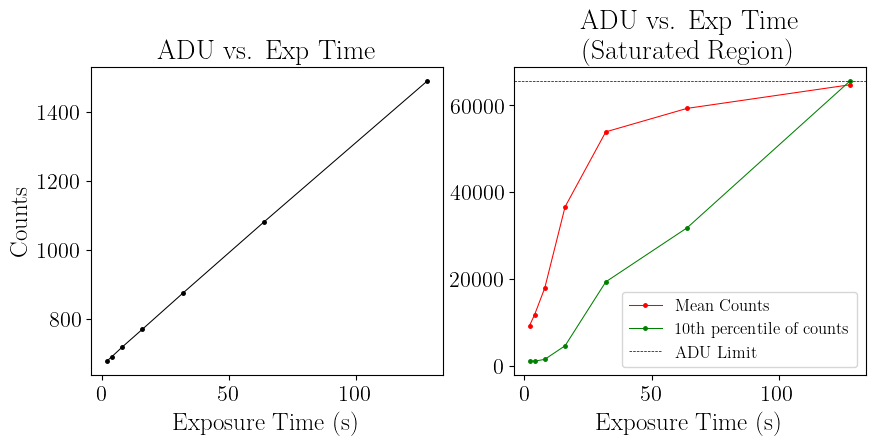

In [121]:
f, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].plot([2, 4, 8, 16, 32, 64, 128], lintest_counts, color='black', marker='o', ms=2.5, lw=0.75)

axs[1].plot([2, 4, 8, 16, 32, 64, 128], lintest_sat_counts, color='red', marker='o', ms=2.5, lw=0.75, label='Mean Counts')
axs[1].plot([2, 4, 8, 16, 32, 64, 128], lintest_sat_counts_10, color='green', marker='o', ms=2.5, lw=0.75, 
            label='10th percentile of counts')
axs[1].axhline(2**16, color='black', lw=0.5, ls='--', label='ADU Limit')
axs[1].legend()

axs[0].set_ylabel('Counts')
axs[0].set_xlabel('Exposure Time (s)')
axs[0].set_title('ADU vs. Exp Time')

axs[1].set_xlabel('Exposure Time (s)')
axs[1].set_title('ADU vs. Exp Time')
axs[1].set_title('''ADU vs. Exp Time
(Saturated Region)''')

# 2) Aperture Photometry in PG1633+099

Found clear evidence that signal-to-noise peaks for an aperture radius of 4 pixels! Initially struggled as I chose a star that was too bright, but scaling it down helped reveal the differences in S/N and the clear common pattern of returns

In [7]:
pg_fnums = np.concatenate([np.arange(81, 93, 1), np.arange(130, 140, 1), np.arange(202, 212, 1)])
pg_fnums = [f'0{x}' if (len(str(x)) == 2) else str(x) for x in pg_fnums]
pg_fnames = np.sort([f'{reduced_dir}/a{x}_otzdf.fits' for x in pg_fnums])

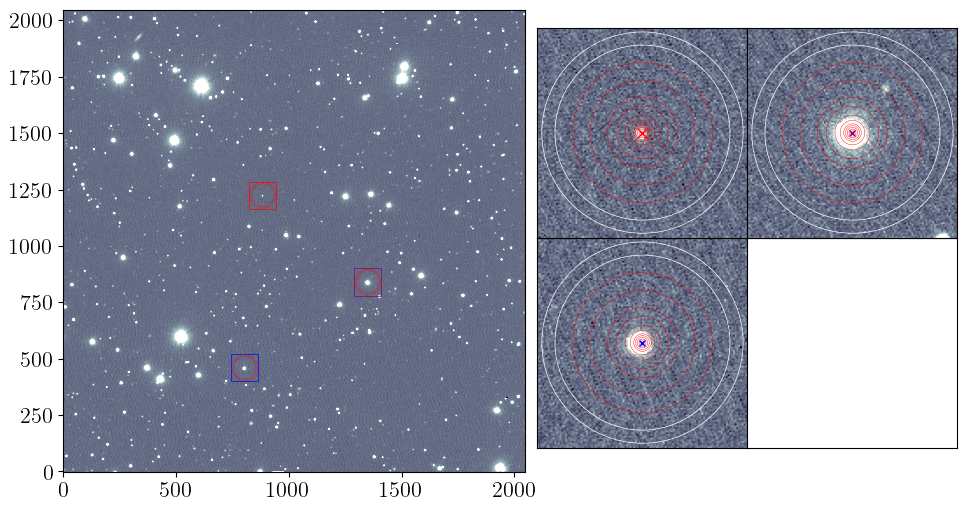

In [1215]:
pg_standard = fits.open(pg_fnames[4])[0].data # V band! a085

# Positions and apertures
target_stars = {
    '0': (885, 1225),
    '1': (1351, 840),
    '2': (805, 460),
}

positions_ = list(target_stars.values())

target_stars = {
    '0': (1225, 885),
    '1': (840, 1351),
    '2': (460, 805),
}

# old: 0: (614, 1707), 1: (990, 1050), # (1351, 840), 2: (998, 1640)


positions = list(target_stars.values())
rs = [1, 2, 3, 4, 5, 7, 10, 15, 20, 30, 40]
aps = [CircularAperture(positions_, r=rs[i]) for i in range(len(rs))]


f, axs = plt.subplots(1, 2, figsize=(14, 6))
axs[1].remove()

ax1 = f.add_axes([0.475, 0.15, 0.15, 0.35])
ax2 = f.add_axes([0.475, 0.5, 0.15, 0.35])
ax3 = f.add_axes([0.625, 0.15, 0.15, 0.35])
ax4 = f.add_axes([0.625, 0.5, 0.15, 0.35])
axs_ = [ax2, ax4, ax1, ax3]

rect1 = matplotlib.patches.Rectangle((positions[0][1] - 60, positions[0][0] - 60), 120, 120, edgecolor='red', facecolor=(1, 1, 1, 0), lw=0.5)
rect2 = matplotlib.patches.Rectangle((positions[1][1] - 60, positions[1][0] - 60), 120, 120, edgecolor='purple', facecolor=(1, 1, 1, 0), lw=0.5)
rect3 = matplotlib.patches.Rectangle((positions[2][1] - 60, positions[2][0] - 60), 120, 120, edgecolor='blue', facecolor=(1, 1, 1, 0), lw=0.5)

axs[0].add_patch(rect1)
axs[0].add_patch(rect2)
axs[0].add_patch(rect3)

vmin, vmax = ZScaleInterval().get_limits(pg_standard)
axs[0].imshow(pg_standard, origin='lower', vmin=vmin, vmax=vmax, cmap='bone')

axs_[0].imshow(pg_standard[positions[0][0] - 60 : positions[0][0] + 60, positions[0][1] - 60 : positions[0][1] + 60], origin='lower', vmin=vmin, vmax=vmax, 
               extent=[positions[0][1] - 60, positions[0][1] + 60, positions[0][0] - 60, positions[0][0] + 60], cmap='bone')

axs_[1].imshow(pg_standard[positions[1][0] - 60 : positions[1][0] + 60, positions[1][1] - 60 : positions[1][1] + 60], origin='lower', vmin=vmin, vmax=vmax, 
               extent=[positions[1][1] - 60, positions[1][1] + 60, positions[1][0] - 60, positions[1][0] + 60], cmap='bone')

axs_[2].imshow(pg_standard[positions[2][0] - 60 : positions[2][0] + 60, positions[2][1] - 60 : positions[2][1] + 60], origin='lower', vmin=vmin, vmax=vmax, 
               extent=[positions[2][1] - 60, positions[2][1] + 60, positions[2][0] - 60, positions[2][0] + 60], cmap='bone')

axs_[0].plot(*positions_[0], color='red', ms=7, marker='x')
axs_[1].plot(*positions_[1], color='purple', ms=4, marker='x')
axs_[2].plot(*positions_[2], color='blue', ms=5, marker='x')

ax1.set_xticks([])
ax1.set_yticks([])
ax2.set_xticks([])
ax2.set_yticks([])
ax3.set_xticks([])
ax3.set_yticks([])
ax4.set_xticks([])
ax4.set_yticks([])


phot_table = aperture_photometry(pg_standard, aps, method='subpixel', subpixels=5)
phot_table.rename_columns([f'aperture_sum_{i}' for i in range(len(rs))], [f'S{i}' for i in range(len(rs))])

annulus_aperture = CircularAnnulus(positions_, r_in=50, r_out=57.5)
back_table = aperture_photometry(pg_standard, annulus_aperture, method='subpixel', subpixels=5)

ann_patches = annulus_aperture.plot(color='red', lw=0.25, label='Background annulus', ax=axs[0])
ann_patches = annulus_aperture[0].plot(color='white', lw=0.5, label='Background annulus', ax=axs_[0])
ann_patches = annulus_aperture[1].plot(color='white', lw=0.5, label='Background annulus', ax=axs_[1])
ann_patches = annulus_aperture[2].plot(color='white', lw=0.5, label='Background annulus', ax=axs_[2])
[[aps[j][i].plot(ax=axs_[i], lw=0.3, color='red') for i in range(3)] for j in range(len(rs))]

plt.show()

### Calculating S/N

In [353]:
phot_table['B0'] = back_table['aperture_sum'] / annulus_aperture.area * aps[0].area
phot_table['B1'] = back_table['aperture_sum'] / annulus_aperture.area * aps[1].area
phot_table['B2'] = back_table['aperture_sum'] / annulus_aperture.area * aps[2].area
phot_table['B3'] = back_table['aperture_sum'] / annulus_aperture.area * aps[3].area
phot_table['B4'] = back_table['aperture_sum'] / annulus_aperture.area * aps[4].area
phot_table['B5'] = back_table['aperture_sum'] / annulus_aperture.area * aps[5].area
phot_table['B6'] = back_table['aperture_sum'] / annulus_aperture.area * aps[6].area
phot_table['B7'] = back_table['aperture_sum'] / annulus_aperture.area * aps[7].area
phot_table['B8'] = back_table['aperture_sum'] / annulus_aperture.area * aps[8].area
phot_table['B9'] = back_table['aperture_sum'] / annulus_aperture.area * aps[9].area
phot_table['B10'] = back_table['aperture_sum'] / annulus_aperture.area * aps[10].area
# phot_table['B11'] = back_table['aperture_sum'] / annulus_aperture.area * aps[11].area

phot_table['sigB'] = back_table['aperture_sum'] / annulus_aperture.area
sigRN = 14.746


sns = [(phot_table[f'S{i}'] - phot_table[f'B{i}']) / ((phot_table[f'S{i}'] - phot_table[f'B{i}']) +\
                aps[i].area * (phot_table['sigB']**2 + sigRN**2))**(1. / 2) for i in range(len(rs))]

phot_table['SN0'] = sns[0]
phot_table['SN1'] = sns[1]
phot_table['SN2'] = sns[2]
phot_table['SN3'] = sns[3]
phot_table['SN4'] = sns[4]
phot_table['SN5'] = sns[5]
phot_table['SN6'] = sns[6]
phot_table['SN7'] = sns[7]
phot_table['SN8'] = sns[8]
phot_table['SN9'] = sns[9]
phot_table['SN10'] = sns[10]

phot_table

id,xcenter,ycenter,S0,S1,S2,S3,S4,S5,S6,S7,S8,S9,S10,B0,B1,B2,B3,B4,B5,B6,B7,B8,B9,B10,sigB,SN0,SN1,SN2,SN3,SN4,SN5,SN6,SN7,SN8,SN9,SN10
,pix,pix,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,885.0,1225.0,770.5925400740815,3230.743377287239,6373.309506613284,9858.598210758619,13666.24080792834,23178.40121912139,42549.64099244683,90477.93409912009,157182.7662609928,346850.7773436877,613445.4010572952,381.1933945196914,1524.7735780787657,3430.740550677223,6099.094312315063,9529.834862992286,18678.476331464877,38119.33945196914,85768.51376693057,152477.35780787657,343074.0550677223,609909.4312315063,121.3376260235758,1.7899744227596721,3.9194311784799067,4.511738751700908,4.327450609365479,3.8118425276905894,2.964344667707498,2.043969195165517,1.4488562881907,1.0858225185181585,0.5810591033047672,0.40802264104810354
2,1351.0,840.0,37632.91670612888,157687.62166472833,297913.15953430586,404165.9729081065,464161.72316029086,513339.464058613,548357.0590548906,606423.6287230281,678885.2853239339,875476.8892968623,1146111.9947711248,381.4969490910984,1525.9877963643935,3433.4725418198855,6103.951185457574,9537.42372727746,18693.35050546382,38149.69490910984,85836.81354549713,152598.77963643937,343347.25418198854,610395.1185457575,121.43425044465091,128.33013593015062,266.17550518572267,347.6350230560796,371.1591338373551,356.10318792176764,295.7062433730388,223.50018468776872,156.26954859728846,119.70256506203214,81.29940414412926,61.551616488453945
3,805.0,460.0,8750.268418331636,39236.14182274637,80835.92630493303,117858.69624802703,141517.62465403602,165374.27263810206,190050.2437217175,240810.21066779725,309326.3824755625,501835.60920486937,769430.3309356058,380.96323053530375,1523.852922141215,3428.669074817734,6095.41168856486,9524.080763382595,18667.198296229883,38096.32305353038,85716.72687044335,152385.29221412152,342866.9074817734,609541.1688564861,121.26436255190175,35.606105937522656,79.46320558879586,109.54373234114432,120.38806994474956,115.5881636950258,93.84564908380213,69.07001773531239,47.40641704845691,36.09119736939619,24.427452346116507,18.441704881442412


Text(0.5, 1.0, 'Howell Figure (S/N vs. $R_{\\mathrm{aperture}}$)')

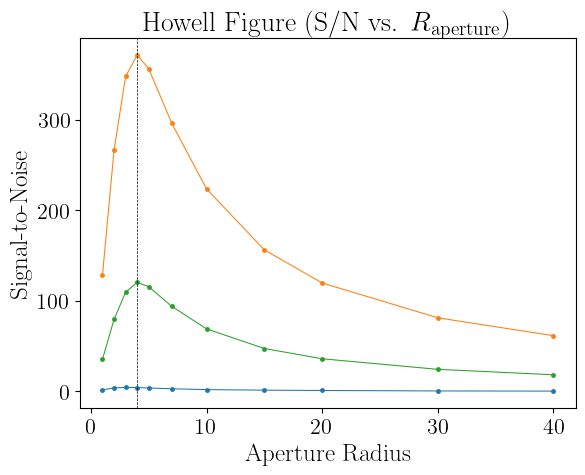

In [ ]:
sns0 = [phot_table[f'SN{i}'][0] for i in range(len(rs))]
sns1 = [phot_table[f'SN{i}'][1] for i in range(len(rs))]
sns2 = [phot_table[f'SN{i}'][2] for i in range(len(rs))]

f, ax = plt.subplots()

ax.plot(rs, sns0, marker='o', ms=2.5, lw=0.75)
ax.plot(rs, sns1, marker='o', ms=2.5, lw=0.75)
ax.plot(rs, sns2, marker='o', ms=2.5, lw=0.75)
ax.axvline(4, color='black', ls='--', lw=0.5)
ax.set_xlabel('Aperture Radius')
ax.set_ylabel('Signal-to-Noise')

ax.set_title('Howell Figure (S/N vs. $R_{\mathrm{aperture}}$)')

# 3) Identifying Standard Stars (Landolt 1992)

In [459]:
r_aperture = 4

standard_stars = {
    'A': (1045, 1044),
    'B': (1253, 1223), 
    'C': (1365, 1232),
    'D': (1445, 1183),
}

# standard_stars = {
#     'A': (1112, 1147),
#     'B': (1223, 1253), 
#     'C': (1232, 1365),
#     'D': (1183, 1445),
# }

standard_positions = list(standard_stars.values())

# 4) Instrumental Magnitudes for Standard Stars
Retrospectively, I'm pretty sure these instrumental magnitudes are about 2-3 magnitudes too bright. I'm not sure why - maybe something to do with my otzdf process, but this error propagates and gives me some trouble in the extinction coefficients and color coefficients section.

$$-2.5 \times \log(S) = -2.5 \times \log(T - AB)$$
$T$ = Total Signal ;
$A$ = Aperture Area ;
$B$ = Mean Background

In [ ]:
aperture = CircularAperture(standard_positions, r=r_aperture)
ap_ann = CircularAnnulus(standard_positions, r_in=30, r_out=37.5)

ap_phot = aperture_photometry(pg_standard, aperture, method='subpixel', subpixels=5)
ap_ann_phot = aperture_photometry(pg_standard, ap_ann, method='subpixel', subpixels=5)

T = np.array(ap_phot['aperture_sum'])
A = aperture.area
B = np.array(ap_ann_phot['aperture_sum'] / ap_ann.area)

print(T - A * B)
inst_mags = -2.5 * np.log10(T - A * B)
inst_mags

[109423.9126396  795691.27297801 674070.15574979 458801.21050685]


array([-12.5977806 , -14.75186149, -14.57176275, -14.15406139])

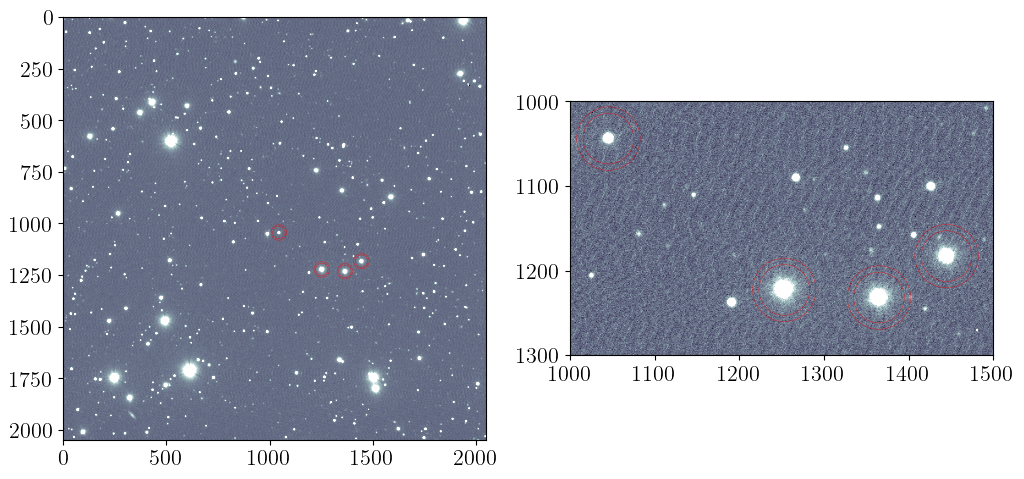

In [544]:
f, axs = plt.subplots(1, 2, figsize=(12, 6))

vmin, vmax = ZScaleInterval().get_limits(pg_standard)
axs[0].imshow(pg_standard, vmin=vmin, vmax=vmax, cmap='bone')
axs[1].imshow(pg_standard[1000:1300, 1000:1500], extent=[1000, 1500, 1300, 1000], vmin=vmin, vmax=vmax, cmap='bone')

ann_patches = ap_ann.plot(color='red', lw=0.25, label='Background annulus', ax=axs[0])
ann_patches = ap_ann.plot(color='red', lw=0.25, label='Background annulus', ax=axs[1])

plt.show()

# 5) Instrumental Magnitudes vs. Airmass
Plotting instrumental magnitudes vs. airmass required repositioning each frame as images in different filters were slightly dithered with respect to one another. Nonetheless, being sure to choose frames which had the same exposure time, I found that magnitudes increase (or dim) for observations taken in higher airmass. The exact relationship was not as linear as I had hoped. I alleviated this a bit by switching my choice of files, but I still found no perfect solution to finding a better linear trend.

In [ ]:
airmass = dict(zip(df['fnum'].values, [] * len(df)))
for i in df['fnum'].values:
    if i in np.arange(81, 93, 1):
        airmass[i] = 1.18
        pass
    elif i in np.arange(130, 140, 1):
        airmass[i] = 1.24
        pass
    elif i in np.arange(202, 212, 1):
        airmass[i] = 1.51
        pass
    elif i in [237, 238, 239, 241, 242, 243, 244, 245, 246]:
        airmass[i] = 2.2
    else:
        airmass[i] = 0
    
df['X'] = list(airmass.values())

In [1114]:
# Choose values, sorted by Xs
X = [1.18, 1.24, 1.51, 2.20]
# ufns = [82, 130, 202, 237]
# bfns = [83, 133, 204, 239]
# vfns = [86, 134, 206, 241]
# rfns = [87, 136, 208, 243]
# ifns = [89, 139, 210, 245]

# ufns = ['082', '130', '202', '237']
# bfns = ['083', '133', '204', '239']
# vfns = ['086', '134', '206', '241']
# rfns = ['087', '136', '208', '243']
# ifns = ['089', '139', '210', '245']

ufns = ['082', '131', '202', '237']
bfns = ['083', '132', '204', '239']
vfns = ['086', '135', '206', '241']
rfns = ['087', '137', '208', '243']
ifns = ['089', '138', '210', '245']

df[['objname', 'fnum', 'X', 'filter']][(df['objname'] == 'PG1633+099') &\
            (df['X'] != 0.) & (
                df['filter'] != 'Ha')].sort_values(by='filter')

,objname,fnum,X,filter
216,PG1633+099,239,2.20,B
82,PG1633+099,83,1.18,B
198,PG1633+099,205,1.51,B
197,PG1633+099,204,1.51,B
132,PG1633+099,133,1.24,B
131,PG1633+099,132,1.24,B
138,PG1633+099,139,1.24,I
204,PG1633+099,211,1.51,I
203,PG1633+099,210,1.51,I
222,PG1633+099,245,2.20,I


## Adjusting positions and applying extinction corrections

In [1115]:
def adjust_position(x, ely):
    xnew = []
    for elx in x:
        elx = tuple((elx[0] + ely[0], elx[1] + ely[1]))
        xnew.append(elx)

    return xnew

Text(0, 0.5, 'I')

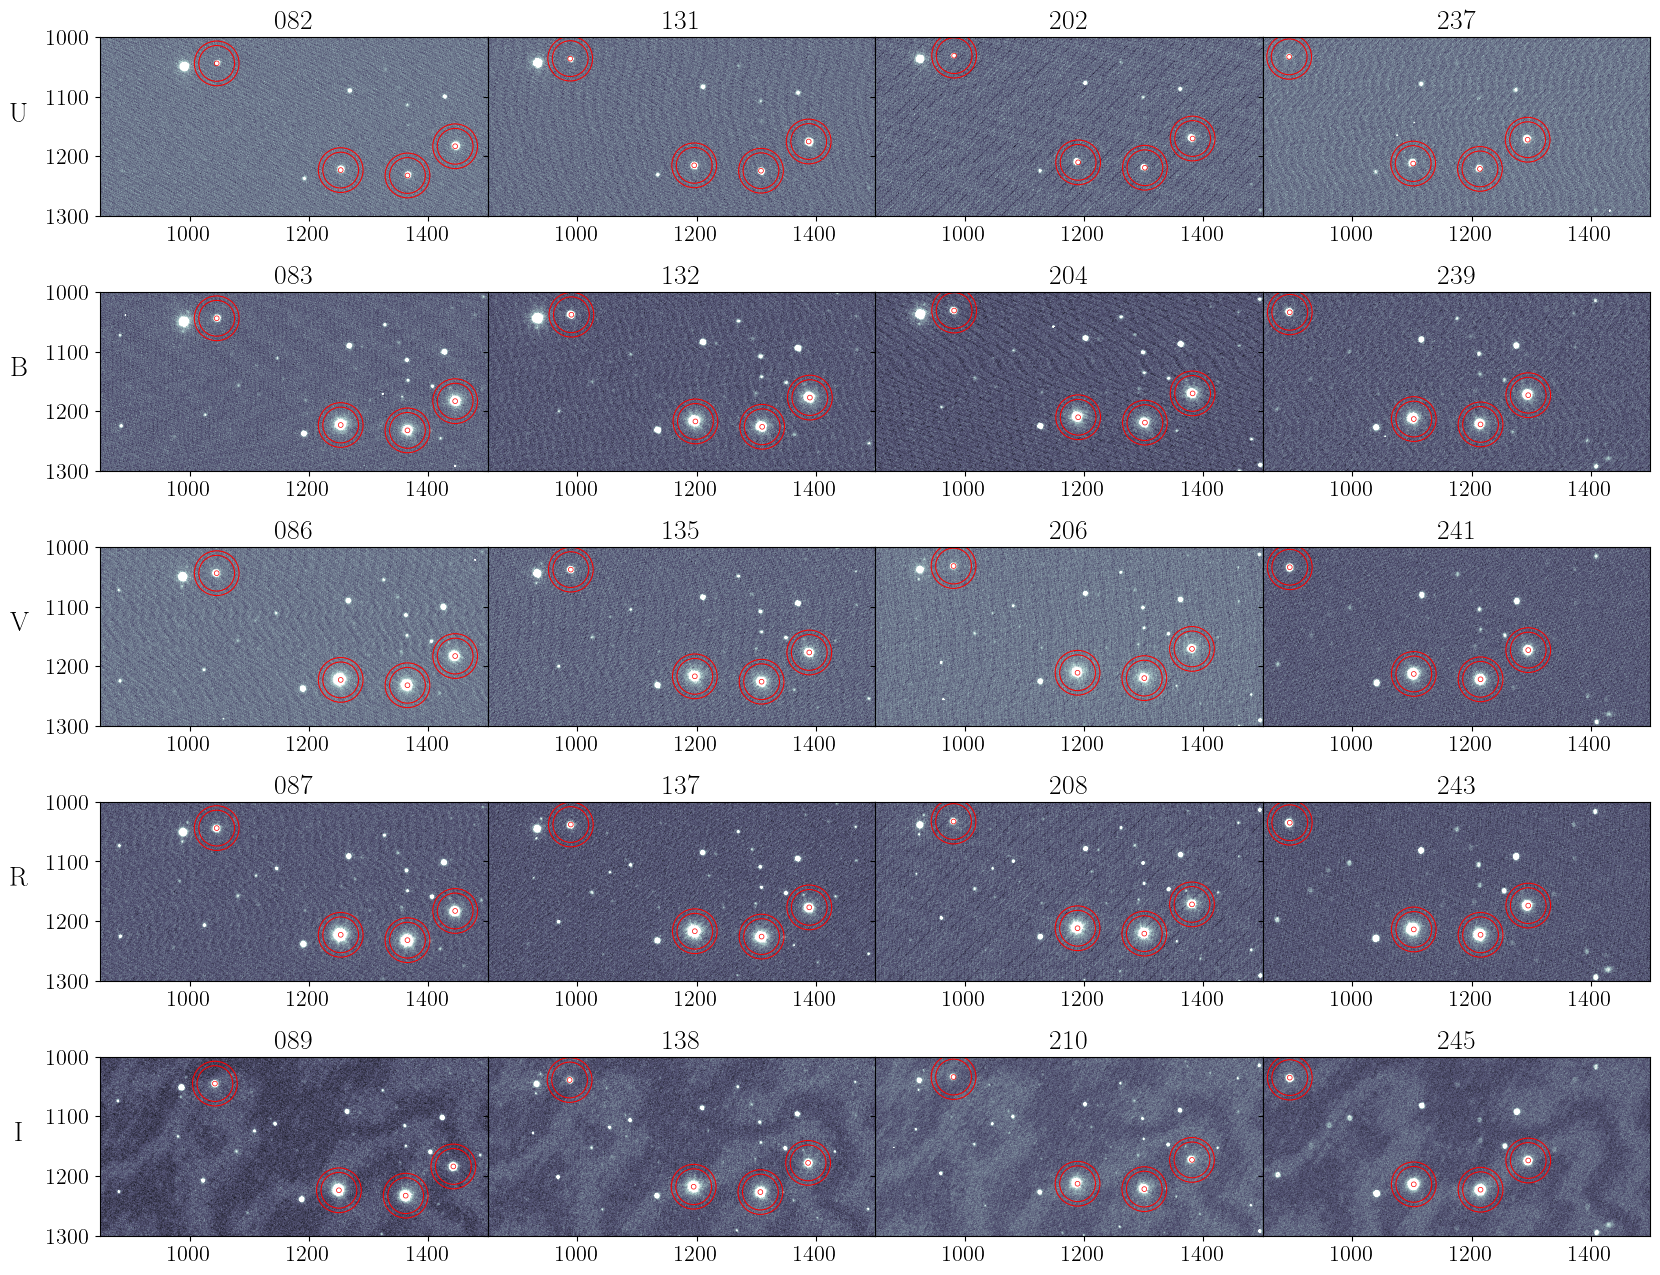

In [1117]:
full_fns = []

f, axs = plt.subplots(5, 4, figsize=(20, 16), sharex=False, sharey=True)
f.subplots_adjust(wspace=0, hspace=.2)

adjustment = [(0, 0), (-57, -8), (-63, -13), (-151, -11), 
              (0, 0), (-55, -6), (-63, -13), (-150, -10), 
              (0, 0), (-56, -6), (-64, -12), (-150, -10), 
              (0, 0), (-56, -6), (-64, -11), (-150, -9), 
              (-3, 1), (-58, -5), (-64, -10), (-150, -9),
              ]

stan_pz = []
for i, fn_str in enumerate(ufns + bfns + vfns + rfns + ifns):
    ax = axs[i // 4, i % 4]

    fn = f'{reduced_dir}/a{fn_str}_otzdf.fits'
    dat = fits.open(fn)[0].data

    vmin, vmax = ZScaleInterval().get_limits(dat)
    ax.imshow(dat[1000:1300, 850:1500], extent=[850, 1500, 1300, 1000], vmin=vmin, vmax=vmax, cmap='bone')

    stan_ps = adjust_position(standard_positions, adjustment[i])
    stan_pz.append(stan_ps)
    aperture = CircularAperture(stan_ps, r=r_aperture)
    ap_ann = CircularAnnulus(stan_ps, r_in=30, r_out=37.5)

    ap_patches = aperture.plot(color='red', lw=0.5, label='Background annulus', ax=ax)
    ann_patches = ap_ann.plot(color='red', lw=0.75, label='Background annulus', ax=ax)
    ax.set_title(fn_str)

axs[0, 0].set_ylabel('U', rotation=0, labelpad=20, fontsize=20)
axs[1, 0].set_ylabel('B', rotation=0, labelpad=20, fontsize=20)
axs[2, 0].set_ylabel('V', rotation=0, labelpad=20, fontsize=20)
axs[3, 0].set_ylabel('R', rotation=0, labelpad=20, fontsize=20)
axs[4, 0].set_ylabel('I', rotation=0, labelpad=20, fontsize=20)

In [1118]:
inst_mags = []

for stan_p, fn_str in zip(stan_pz, ufns + bfns + vfns + rfns + ifns):
    fn = f'{reduced_dir}/a{fn_str}_otzdf.fits'
    dat = fits.open(fn)[0].data
    
    aperture = CircularAperture(stan_p, r=r_aperture)
    ap_ann = CircularAnnulus(stan_p, r_in=17.5, r_out=25)

    ap_phot = aperture_photometry(dat, aperture, method='subpixel', subpixels=5)
    ap_ann_phot = aperture_photometry(dat, ap_ann, method='subpixel', subpixels=5)

    T = np.array(ap_phot['aperture_sum'])
    A = aperture.area
    B = np.array(ap_ann_phot['aperture_sum'] / ap_ann.area)

    inst_mag = -2.5 * np.log10(T - A * B)
    inst_mags.append(inst_mag)

inst_mags

[array([ -9.83774045, -11.26489665, -10.94537529, -12.08372298]),
 array([ -9.88404009, -11.37037406, -10.96501945, -12.10050471]),
 array([ -9.80174035, -10.89685715, -10.63562784, -11.76250327]),
 array([ -9.30556786, -10.42466453, -10.14124314, -11.27885049]),
 array([-12.11334339, -14.15711161, -13.92481803, -13.9906679 ]),
 array([-11.85094399, -13.61008692, -13.46153944, -13.51337886]),
 array([-11.99938023, -13.85635993, -13.6642561 , -13.71187759]),
 array([-11.62451182, -13.30503099, -13.16449054, -13.19313196]),
 array([-11.7499712 , -13.72149162, -13.61412969, -13.20180459]),
 array([-11.81651151, -13.86311368, -13.71380211, -13.285     ]),
 array([-11.86415007, -13.89489565, -13.74165801, -13.32392208]),
 array([-11.50871735, -13.59114316, -13.40965287, -12.99478233]),
 array([-12.36786682, -14.62685937, -14.46249557, -13.74340425]),
 array([-12.37451558, -14.52071346, -14.39071077, -13.67904984]),
 array([-12.38627382, -14.47834179, -14.39046721, -13.68288136]),
 array([-1

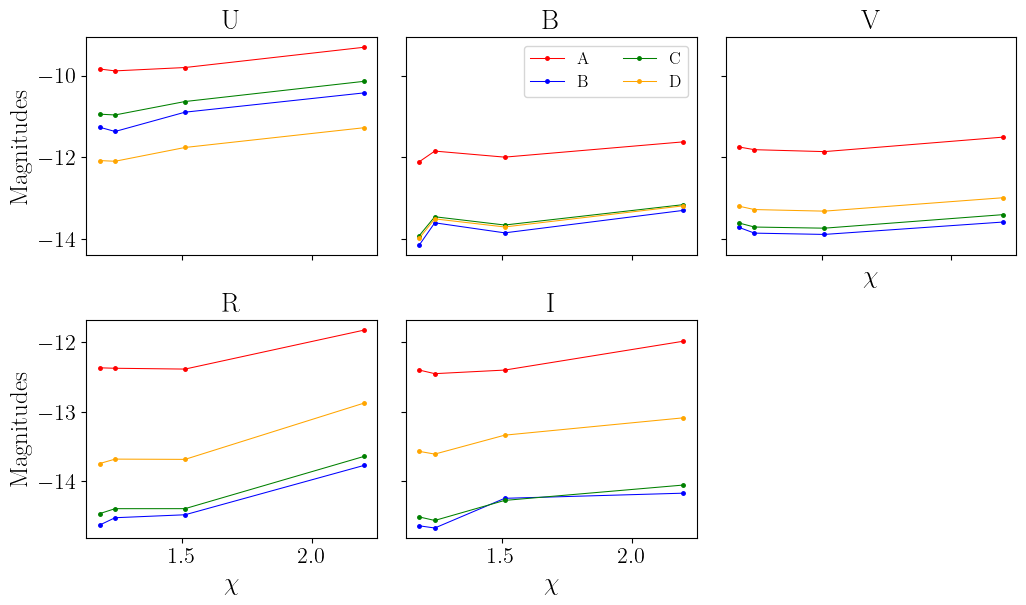

In [ ]:
f, axs = plt.subplots(2, 3, figsize=(12, 6.5), sharey='row', sharex='col')
f.subplots_adjust(hspace=0.3, wspace=0.1)

axs[1, 2].remove()

UA = np.array(inst_mags[:4])[:, 0]
UB = np.array(inst_mags[:4])[:, 1]
UC = np.array(inst_mags[:4])[:, 2]
UD = np.array(inst_mags[:4])[:, 3]

BA = np.array(inst_mags[4:8])[:, 0]
BB = np.array(inst_mags[4:8])[:, 1]
BC = np.array(inst_mags[4:8])[:, 2]
BD = np.array(inst_mags[4:8])[:, 3]

VA = np.array(inst_mags[8:12])[:, 0]
VB = np.array(inst_mags[8:12])[:, 1]
VC = np.array(inst_mags[8:12])[:, 2]
VD = np.array(inst_mags[8:12])[:, 3]

RA = np.array(inst_mags[12:16])[:, 0]
RB = np.array(inst_mags[12:16])[:, 1]
RC = np.array(inst_mags[12:16])[:, 2]
RD = np.array(inst_mags[12:16])[:, 3]

IA = np.array(inst_mags[16:20])[:, 0]
IB = np.array(inst_mags[16:20])[:, 1]
IC = np.array(inst_mags[16:20])[:, 2]
ID = np.array(inst_mags[16:20])[:, 3]

axs[0, 0].plot(X, UA, marker='o', ms=2.5, lw=0.75, color='red')
axs[0, 0].plot(X, UB, marker='o', ms=2.5, lw=0.75, color='blue')
axs[0, 0].plot(X, UC, marker='o', ms=2.5, lw=0.75, color='green')
axs[0, 0].plot(X, UD, marker='o', ms=2.5, lw=0.75, color='orange')

axs[0, 1].plot(X, BA, marker='o', ms=2.5, lw=0.75, color='red', label='A')
axs[0, 1].plot(X, BB, marker='o', ms=2.5, lw=0.75, color='blue', label='B')
axs[0, 1].plot(X, BC, marker='o', ms=2.5, lw=0.75, color='green', label='C')
axs[0, 1].plot(X, BD, marker='o', ms=2.5, lw=0.75, color='orange', label='D')

axs[0, 2].plot(X, VA, marker='o', ms=2.5, lw=0.75, color='red')
axs[0, 2].plot(X, VB, marker='o', ms=2.5, lw=0.75, color='blue')
axs[0, 2].plot(X, VC, marker='o', ms=2.5, lw=0.75, color='green')
axs[0, 2].plot(X, VD, marker='o', ms=2.5, lw=0.75, color='orange')

axs[1, 0].plot(X, RA, marker='o', ms=2.5, lw=0.75, color='red')
axs[1, 0].plot(X, RB, marker='o', ms=2.5, lw=0.75, color='blue')
axs[1, 0].plot(X, RC, marker='o', ms=2.5, lw=0.75, color='green')
axs[1, 0].plot(X, RD, marker='o', ms=2.5, lw=0.75, color='orange')

axs[1, 1].plot(X, IA, marker='o', ms=2.5, lw=0.75, color='red')
axs[1, 1].plot(X, IB, marker='o', ms=2.5, lw=0.75, color='blue')
axs[1, 1].plot(X, IC, marker='o', ms=2.5, lw=0.75, color='green')
axs[1, 1].plot(X, ID, marker='o', ms=2.5, lw=0.75, color='orange')

axs[0, 2].set_xlabel('$\chi$')
axs[1, 0].set_xlabel('$\chi$')
axs[1, 1].set_xlabel('$\chi$')
axs[0, 0].set_ylabel('Magnitudes')
axs[1, 0].set_ylabel('Magnitudes')
axs[0, 0].set_title('U')
axs[0, 1].set_title('B')
axs[0, 2].set_title('V')
axs[1, 0].set_title('R')
axs[1, 1].set_title('I')

axs[0, 1].legend(ncols=2)


In [ ]:
V_A = 15.256
V_B = 12.969
V_C = 13.229
V_D = 13.691

Star_A = [0.32 + 0.873 + V_A, 0.873 + V_A, V_A, V_A - 0.505, V_A - 1.015]
Star_B = [1.007 + 1.081 + V_B, 1.081 + V_B, V_B, V_B - 0.590, V_B - 1.090]
Star_C = [1.138 + 1.134 + V_C, 1.134 + V_C, V_C, V_C - 0.618, V_C - 1.138]
Star_D = [-0.025 + 0.535 + V_D, 0.535 + V_D, V_D, V_D - 0.324, V_D - 0.650]

starmags = np.array([Star_A, Star_B, Star_C, Star_D])

## Accepted - instrumental mags vs. Airmass

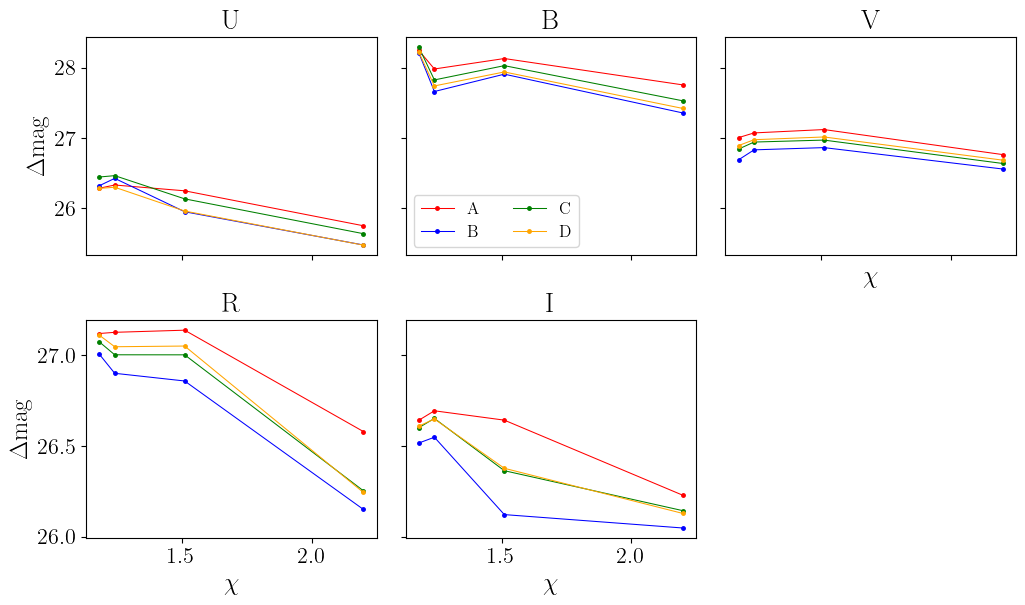

In [828]:
f, axs = plt.subplots(2, 3, figsize=(12, 6.5), sharey='row', sharex='col')
f.subplots_adjust(hspace=0.3, wspace=0.1)

axs[1, 2].remove()
axs[0, 0].plot(X, starmags[0, 0] - UA, marker='o', ms=2.5, lw=0.75, color='red')
axs[0, 0].plot(X, starmags[1, 0] - UB, marker='o', ms=2.5, lw=0.75, color='blue')
axs[0, 0].plot(X, starmags[2, 0] - UC, marker='o', ms=2.5, lw=0.75, color='green')
axs[0, 0].plot(X, starmags[3, 0] - UD, marker='o', ms=2.5, lw=0.75, color='orange')

axs[0, 1].plot(X, starmags[0, 1] - BA, marker='o', ms=2.5, lw=0.75, color='red', label='A')
axs[0, 1].plot(X, starmags[1, 1] - BB, marker='o', ms=2.5, lw=0.75, color='blue', label='B')
axs[0, 1].plot(X, starmags[2, 1] - BC, marker='o', ms=2.5, lw=0.75, color='green', label='C')
axs[0, 1].plot(X, starmags[3, 1] - BD, marker='o', ms=2.5, lw=0.75, color='orange', label='D')

axs[0, 2].plot(X, starmags[0, 2] - VA, marker='o', ms=2.5, lw=0.75, color='red')
axs[0, 2].plot(X, starmags[1, 2] - VB, marker='o', ms=2.5, lw=0.75, color='blue')
axs[0, 2].plot(X, starmags[2, 2] - VC, marker='o', ms=2.5, lw=0.75, color='green')
axs[0, 2].plot(X, starmags[3, 2] - VD, marker='o', ms=2.5, lw=0.75, color='orange')

axs[1, 0].plot(X, starmags[0, 3] - RA, marker='o', ms=2.5, lw=0.75, color='red')
axs[1, 0].plot(X, starmags[1, 3] - RB, marker='o', ms=2.5, lw=0.75, color='blue')
axs[1, 0].plot(X, starmags[2, 3] - RC, marker='o', ms=2.5, lw=0.75, color='green')
axs[1, 0].plot(X, starmags[3, 3] - RD, marker='o', ms=2.5, lw=0.75, color='orange')

axs[1, 1].plot(X, starmags[0, 4] - IA, marker='o', ms=2.5, lw=0.75, color='red')
axs[1, 1].plot(X, starmags[1, 4] - IB, marker='o', ms=2.5, lw=0.75, color='blue')
axs[1, 1].plot(X, starmags[2, 4] - IC, marker='o', ms=2.5, lw=0.75, color='green')
axs[1, 1].plot(X, starmags[3, 4] - ID, marker='o', ms=2.5, lw=0.75, color='orange')

axs[0, 2].set_xlabel('$\chi$')
axs[1, 0].set_xlabel('$\chi$')
axs[1, 1].set_xlabel('$\chi$')
axs[0, 0].set_ylabel('$\Delta$mag')
axs[1, 0].set_ylabel('$\Delta$mag')
axs[0, 0].set_title('U')
axs[0, 1].set_title('B')
axs[0, 2].set_title('V')
axs[1, 0].set_title('R')
axs[1, 1].set_title('I')

axs[0, 1].legend(ncols=2)

### Linear fit to extract extinction coefficients

In [818]:
# U-band fits
mU, y0U = np.polyfit(X * 4, np.concatenate([starmags[0, 0] - UA, starmags[1, 0] - UB, 
                                          starmags[2, 0] - UC, starmags[3, 0] - UD]), deg=1)

# B-band fits
mB, y0B = np.polyfit(X * 4, np.concatenate([starmags[0, 1] - BA, starmags[1, 1] - BB, 
                                          starmags[2, 1] - BC, starmags[3, 1] - BD]), deg=1)

# V-band fits
mV, y0V = np.polyfit(X * 4, np.concatenate([starmags[0, 2] - VA, starmags[1, 2] - VB, 
                                          starmags[2, 2] - VC, starmags[3, 2] - VD]), deg=1)

# R-band fits
mR, y0R = np.polyfit(X * 4, np.concatenate([starmags[0, 3] - RA, starmags[1, 3] - RB, 
                                          starmags[2, 3] - RC, starmags[3, 3] - RD]), deg=1)

# I-band fits
mI, y0I = np.polyfit(X * 4, np.concatenate([starmags[0, 4] - IA, starmags[1, 4] - IB, 
                                          starmags[2, 4] - IC, starmags[3, 4] - ID]), deg=1)

## Plotting extinction coefficients

U: -0.77, B: -0.53, V: -0.25, R: -0.76, I: -0.48


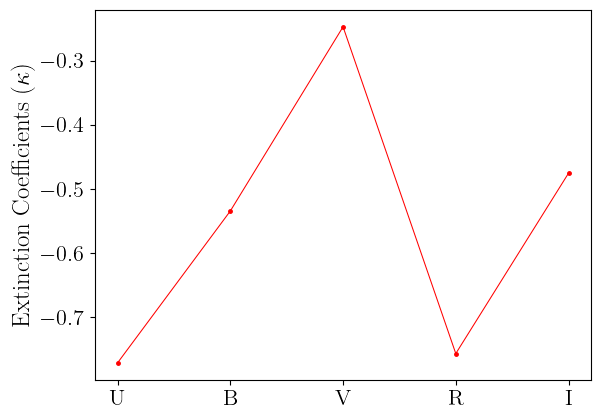

In [826]:
f, ax = plt.subplots()

ax.plot([mU, mB, mV, mR, mI], color='red', ms=2.5, marker='o', lw=0.75)
ax.set_xticks([0, 1, 2, 3, 4])
ax.set_xticklabels(['U', 'B', 'V', 'R', 'I'])
ax.set_ylabel('Extinction Coefficients ($\kappa$)')
print(f'U: {mU:.2f}, B: {mB:.2f}, V: {mV:.2f}, R: {mR:.2f}, I: {mI:.2f}')

### Extinction Correcting Instrumental Magnitudes

In [1088]:
Ks = [mU, mB, mV, mR, mI]
KX = np.repeat(Ks, 4) * np.tile(X, 5)
inst_mags_ecorr = np.array(inst_mags) + np.outer(KX, np.ones(4))
inst_mags_ecorr

array([[-10.74713091, -12.17428712, -11.85476576, -12.99311344],
       [-10.83967075, -12.32600472, -11.92065011, -13.05613537],
       [-10.96545188, -12.06056868, -11.79933937, -12.9262148 ],
       [-11.00104161, -12.12013828, -11.83671689, -12.97432424],
       [-12.74375334, -14.78752156, -14.55522798, -14.62107785],
       [-12.51340868, -14.27255161, -14.12400413, -14.17584355],
       [-12.80609127, -14.66307096, -14.47096714, -14.51858863],
       [-12.7998524 , -14.48037157, -14.33983112, -14.36847254],
       [-12.04196178, -14.01348221, -13.90612028, -13.49379518],
       [-12.12334908, -14.16995125, -14.02063968, -13.59183757],
       [-12.23779904, -14.26854462, -14.11530698, -13.69757106],
       [-12.05310659, -14.1355324 , -13.9540421 , -13.53917156],
       [-13.26030194, -15.51929448, -15.35493068, -14.63583937],
       [-13.31232875, -15.45852663, -15.32852394, -14.61686301],
       [-13.52828824, -15.62035621, -15.53248163, -14.82489578],
       [-13.49163673, -15

# 6) Color corrections
Similar issues to the previous problem. Errors in instrumental magnitudes propagated and cause my zero point fluxes to be WAY higher than they should be. I also found that star A added some outlier points in my analysis, but I figured I should include it nonetheless. This may have thrown off my color correction terms.

### V - R and B - V colors

In [1089]:
VR_A = inst_mags_ecorr[8:12, 0] - inst_mags_ecorr[12:16, 0]
VR_B = inst_mags_ecorr[8:12, 1] - inst_mags_ecorr[12:16, 1]
VR_C = inst_mags_ecorr[8:12, 2] - inst_mags_ecorr[12:16, 2]
VR_D = inst_mags_ecorr[8:12, 3] - inst_mags_ecorr[12:16, 3]

BV_A = inst_mags_ecorr[4:8, 0] - inst_mags_ecorr[8:12, 0]
BV_B = inst_mags_ecorr[4:8, 1] - inst_mags_ecorr[8:12, 1]
BV_C = inst_mags_ecorr[4:8, 2] - inst_mags_ecorr[8:12, 2]
BV_D = inst_mags_ecorr[4:8, 3] - inst_mags_ecorr[8:12, 3]

In [1097]:
real_inst_U = np.concatenate([starmags[0, 0] - inst_mags_ecorr[0:4, 0], starmags[1, 0] - inst_mags_ecorr[0:4, 1], starmags[2, 0] - inst_mags_ecorr[0:4, 2], 
                starmags[3, 0] - inst_mags_ecorr[0:4, 3]])

real_inst_B = np.concatenate([starmags[0, 1] - inst_mags_ecorr[4:8, 0], starmags[1, 1] - inst_mags_ecorr[4:8, 1], starmags[2, 1] - inst_mags_ecorr[4:8, 2], 
                starmags[3, 1] - inst_mags_ecorr[4:8, 3]])

real_inst_V = np.concatenate([starmags[0, 2] - inst_mags_ecorr[8:12, 0], starmags[1, 2] - inst_mags_ecorr[8:12, 1], starmags[2, 2] - inst_mags_ecorr[8:12, 2], 
                starmags[3, 2] - inst_mags_ecorr[8:12, 3]])

real_inst_R = np.concatenate([starmags[0, 3] - inst_mags_ecorr[12:16, 0], starmags[1, 3] - inst_mags_ecorr[12:16, 1], starmags[2, 3] - inst_mags_ecorr[12:16, 2], 
                starmags[3, 3] - inst_mags_ecorr[12:16, 3]])

real_inst_I = np.concatenate([starmags[0, 4] - inst_mags_ecorr[16:, 0], starmags[1, 4] - inst_mags_ecorr[16:, 1], starmags[2, 4] - inst_mags_ecorr[16:, 2], 
                starmags[3, 4] - inst_mags_ecorr[16:, 3]])

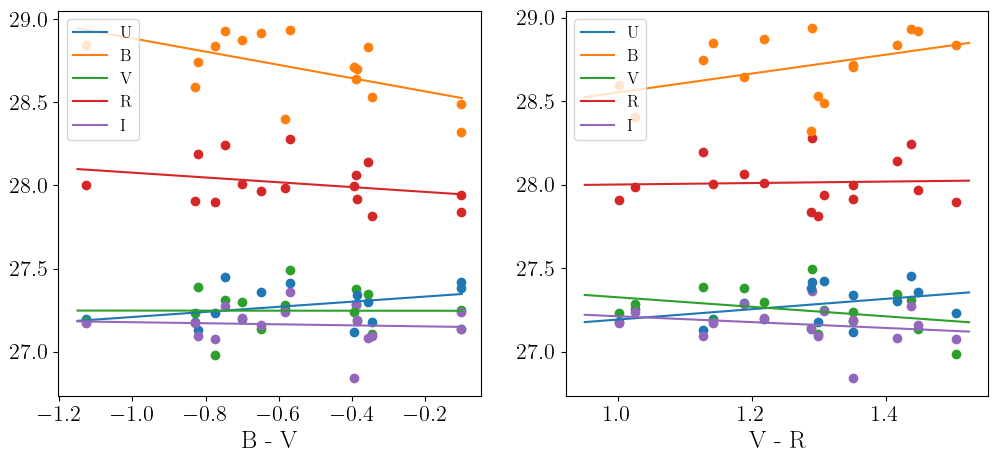

In [1098]:
f, axs = plt.subplots(1, 2, figsize=(12, 5))

[axs[0].scatter(BV_A, starmags[0, i] - inst_mags_ecorr[i * 4 : (i + 1) * 4, 0], color=f'C{i}') for i in range(5)]
[axs[0].scatter(BV_B, starmags[1, i] - inst_mags_ecorr[i * 4 : (i + 1) * 4, 1], color=f'C{i}') for i in range(5)]
[axs[0].scatter(BV_C, starmags[2, i] - inst_mags_ecorr[i * 4 : (i + 1) * 4, 2], color=f'C{i}') for i in range(5)]
[axs[0].scatter(BV_D, starmags[3, i] - inst_mags_ecorr[i * 4 : (i + 1) * 4, 3], color=f'C{i}') for i in range(5)]


[axs[1].scatter(VR_A, starmags[0, i] - inst_mags_ecorr[i * 4 : (i + 1) * 4, 0], color=f'C{i}') for i in range(5)]
[axs[1].scatter(VR_B, starmags[1, i] - inst_mags_ecorr[i * 4 : (i + 1) * 4, 1], color=f'C{i}') for i in range(5)]
[axs[1].scatter(VR_C, starmags[2, i] - inst_mags_ecorr[i * 4 : (i + 1) * 4, 2], color=f'C{i}') for i in range(5)]
[axs[1].scatter(VR_D, starmags[3, i] - inst_mags_ecorr[i * 4 : (i + 1) * 4, 3], color=f'C{i}') for i in range(5)]


# Best fit lines
mUBV, y0UBV = np.polyfit(np.concatenate([BV_A, BV_B, BV_C, BV_D]), real_inst_U, deg=1)
mBBV, y0BBV = np.polyfit(np.concatenate([BV_A, BV_B, BV_C, BV_D]), real_inst_B, deg=1)
mVBV, y0VBV = np.polyfit(np.concatenate([BV_A, BV_B, BV_C, BV_D]), real_inst_V, deg=1)
mRBV, y0RBV = np.polyfit(np.concatenate([BV_A, BV_B, BV_C, BV_D]), real_inst_R, deg=1)
mIBV, y0IBV = np.polyfit(np.concatenate([BV_A, BV_B, BV_C, BV_D]), real_inst_I, deg=1)

mUVR, y0UVR = np.polyfit(np.concatenate([VR_A, VR_B, VR_C, VR_D]), real_inst_U, deg=1)
mBVR, y0BVR = np.polyfit(np.concatenate([VR_A, VR_B, VR_C, VR_D]), real_inst_B, deg=1)
mVVR, y0VVR = np.polyfit(np.concatenate([VR_A, VR_B, VR_C, VR_D]), real_inst_V, deg=1)
mRVR, y0RVR = np.polyfit(np.concatenate([VR_A, VR_B, VR_C, VR_D]), real_inst_R, deg=1)
mIVR, y0IVR = np.polyfit(np.concatenate([VR_A, VR_B, VR_C, VR_D]), real_inst_I, deg=1)

# xBV = np.linspace(-0.5, 1.0, 20)
# xVR = np.linspace(-1.25, 0.5, 20)
xBV = np.linspace(-1.15, -0.1, 20)
xVR = np.linspace(0.95, 1.525, 20)

axs[0].plot(xBV, y0UBV + mUBV * xBV, color='C0', label='U')
axs[0].plot(xBV, y0BBV + mBBV * xBV, color='C1', label='B')
axs[0].plot(xBV, y0VBV + mVBV * xBV, color='C2', label='V')
axs[0].plot(xBV, y0RBV + mRBV * xBV, color='C3', label='R')
axs[0].plot(xBV, y0IBV + mIBV * xBV, color='C4', label='I')

axs[1].plot(xVR, y0UVR + mUVR * xVR, color='C0', label='U')
axs[1].plot(xVR, y0BVR + mBVR * xVR, color='C1', label='B')
axs[1].plot(xVR, y0VVR + mVVR * xVR, color='C2', label='V')
axs[1].plot(xVR, y0RVR + mRVR * xVR, color='C3', label='R')
axs[1].plot(xVR, y0IVR + mIVR * xVR, color='C4', label='I')

axs[0].legend()
axs[1].legend()

axs[0].set_xlabel('B - V')
axs[1].set_xlabel('V - R')
plt.show()

### (V-R) Color
| Band | Zero point (ZP) | First-order color term |
|------|------------------|------------------------|
| U    | 26.8825          | 0.3091                 |
| B    | 27.9877          | 0.5641                 |
| V    | 27.6087          | -0.2842                |
| R    | 27.9561          | 0.0440                 |
| I    | 27.3857          | -0.1746                |

### (B-V) Color
| Band | Zero point (ZP) | First-order color term |
|------|------------------|------------------------|
| U    | 27.3620          | 0.1536                 |
| B    | 28.4857          | -0.3989                |
| V    | 27.2457          | -0.0012                |
| R    | 27.9320          | -0.1447                |
| I    | 27.1456          | -0.0315                |

# 7) Photometry for NGC6823
Grabbed locations with DS9 and performed photometry at each location (I reduced the aperture annulus size a bit since this cluster was pretty densely populated, especially in the V band). I also grabbed a larger second dataset because I realized how easy it was to get positions with DS9.

In [1194]:
ngc_pos0 = [
    (1405.1049, 1079.8038), (1541.5164, 1100.6695), (1573.8999, 1029.3482), 
    (1560.372, 1001.5206), (1465.5553, 962.60603), (1434.6399, 937.75679), 
    (1454.6001, 1154.4118), (1373.8494, 1202.1625), (1343.6319, 1129.0202), 
    (1300.2085, 1155.8085), (1217.1016, 1211.2818), (1123.0736, 1099.585), 
    (1195.313, 977.36243), (1082.7414, 954.39587), (1271.8572, 997.85748), 
    (1323.4286, 922.44536), (1274.6074, 914.35344), (1693.8675, 1197.4757), 
    (1735.946, 1184.9836), (1525.5133, 1196.4394), (1593.5058, 1195.5953), 
    (1544.4243, 1238.7563), (1016.7314, 1321.3237), (993.03876, 1348.4174), 
    (1001.8041, 1429.693), (1038.2773, 1414.6339), (1081.5111, 1415.5144), 
    (1018.9697, 1451.3036), (1245.4012, 1405.493), (1306.4765, 1408.446), 
    (1279.3687, 1435.4415), (1321.567, 1453.1457), (1283.4793, 1259.8349), 
    (1019.377, 1252.0845), (836.48739, 1237.5795), (831.69236, 1343.7386), 
    (705.51206, 1315.8225), (733.5725, 1224.5718), (870.42823, 1486.5182), 
    (686.68798, 1440.6007), (954.41559, 1072.5222), (915.29792, 1035.5828), 
    (826.1739, 935.23536), (757.10615, 876.0928), (705.97917, 999.44927), 
    (148.19553, 1522.4244), (868.44146, 1550.1445), (1386.5964, 1581.5391), 
    (1617.3543, 1443.3709), (1570.4844, 1367.1814), (1501.0772, 895.03936)
] # Positions grabbed from DS9

ngc_pos = [
    (1259.2651, 779.38242), (1242.292, 724.26018), (1187.7025, 706.70434), 
    (889.58349, 1004.336), (890.51826, 1076.3482), (837.44853, 1074.7699), 
    (749.43086, 682.49541), (757.32288, 643.31992), (1779.7512, 1285.3658), 
    (1592.4883, 1307.2394), (1965.8274, 250.45189), (1960.625, 368.30994), 
    (2009.3168, 464.39815), (1519.5385, 284.5146), (1477.9579, 294.72291), 
    (1372.4626, 297.64304), (1482.3447, 449.50055), (1563.4005, 520.59805), 
    (1591.8252, 584.14977), (1347.4947, 682.55406), (1244.5162, 452.39932), 
    (982.25385, 320.57653), (910.55224, 488.22423), (1767.5433, 296.45625), 
    (1817.3406, 254.25118), (1917.3632, 572.66025), (1843.5323, 513.47953), 
    (1669.4691, 376.0056), (1690.5339, 415.4901), (1589.5245, 630.33165), 
    (1619.4884, 679.31154), (1977.4176, 800.74823), (836.60795, 673.93952), 
    (978.71875, 496.7624), (1197.6238, 313.5335), (1508.6124, 60.64953), 
    (1817.5898, 105.30467), (793.73565, 464.1243), (725.57479, 479.55249), 
    (933.65963, 608.87021), (654.86992, 750.53341), (760.56954, 877.11789), 
    (1019.933, 1104.9773), (970.70516, 875.87185), (1276.4489, 844.49086), 
    (1235.8025, 897.66462), (1738.6543, 969.93053), (1678.4255, 1113.2467), 
    (1698.0826, 1198.7517), (1676.2665, 1050.4641), (929.46558, 1176.3807), 
    (662.89711, 1084.0669), (587.52228, 986.52668), (612.59736, 893.57997), 
    (468.55543, 1019.4679), (395.77984, 993.65414), (440.50557, 784.46097), 
    (467.40866, 832.45344), (379.35141, 740.41939), (441.58814, 565.84015), 
    (382.45573, 571.33685), (599.01835, 420.41082), (548.12468, 406.35218), 
    (455.71526, 405.37524), (385.58558, 455.45959), (677.81798, 373.37978), 
    (1061.3164, 444.34347), (1900.8304, 857.49115), (1799.7273, 359.68394), 
    (1133.7746, 1516.568), (872.01178, 1550.676), (874.13784, 1487.5899), 
    (834.5208, 1469.6127), (709.76963, 1317.6808), (734.4164, 1358.4706), 
    (712.46128, 1401.4313), (690.27426, 1441.6889), (718.95391, 1515.5816), 
    (851.74388, 1632.4953), (881.27363, 1675.1197), (991.42727, 1653.6766), 
    (1198.612, 1710.4483), (1335.6595, 1715.8383), (1433.4901, 1759.4617), 
    (1486.7741, 1828.449), (1405.6352, 1877.8789), (1355.6052, 1974.657), 
    (1261.5331, 1900.4652), (1175.5832, 1873.4589), (1096.4227, 1971.6211), 
    (1246.6271, 1975.4065), (1425.5334, 1926.3393), (1583.3744, 1878.4181), 
    (1564.1164, 1514.2734), (1621.4512, 1444.8487), (1566.6469, 1431.4285), 
    (1527.5145, 1381.6379), (1574.6513, 1368.1259), (1464.1358, 1400.5129), 
    (1428.4765, 1512.3326), (1390.7682, 1582.7412), (1362.451, 1628.6093), 
    (1275.9366, 1552.2096), (1008.5405, 1857.685), (1112.4904, 1823.9631), 
    (1086.6432, 1899.485), (984.52142, 1972.518), (1024.4338, 1912.5199), 
    (826.47148, 1933.448), (680.47309, 1740.6282), (704.4816, 1651.4153), 
    (679.49866, 1610.9918), (583.44083, 1479.7067), (495.45376, 1373.3946), 
    (424.30509, 1325.5721), (377.48661, 1397.9531), (334.74842, 1533.8386), 
    (467.62603, 1618.8353), (529.50554, 1659.7303), (478.51171, 1682.5147), 
    (517.48641, 1720.4953), (424.52755, 1716.7554), (403.51488, 1652.4919), 
    (347.42604, 1713.293), (494.54358, 1905.1677), (363.40807, 1895.3342), 
    (353.11093, 1942.3172), (710.30451, 1805.6971), (687.83957, 1870.5757), 
    (638.55065, 1885.8634), (1951.5147, 1153.0982), (1986.7232, 1221.2912), 
    (1959.2465, 1266.3674), (1927.5452, 1330.3814), (1868.4553, 1355.4513), 
    (1798.4306, 1237.7668), (1775.6151, 1139.4249), (1990.4705, 1070.7434), 
    (2010.8229, 926.50037), (1911.5645, 1016.6232), (1820.3494, 1011.5378), 
    (1694.4629, 944.38752), (1529.7308, 1197.2878), (1471.4887, 1245.509), 
    (1465.4785, 1283.5178)
]

Text(0.5, 1.0, 'V')

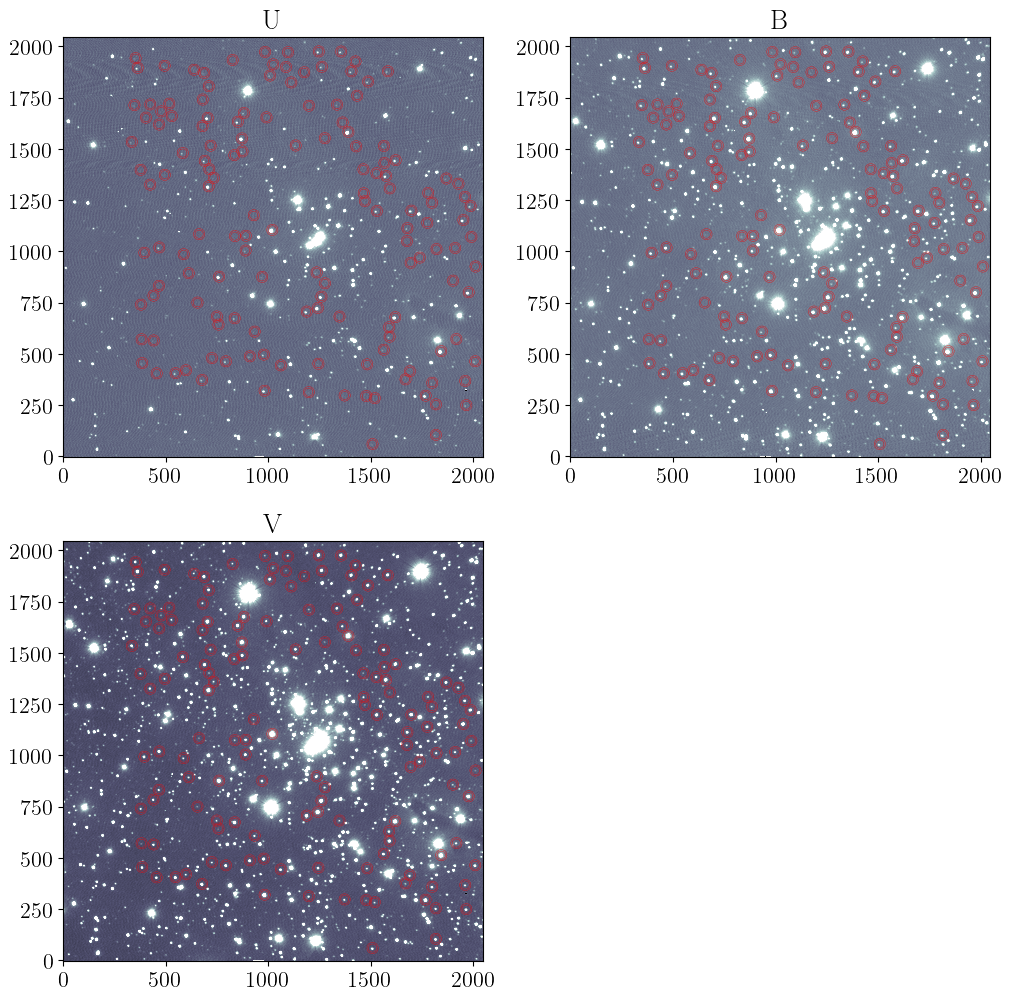

In [1181]:
datU = fits.open(reduced_dir+'a162_otzdf.fits')[0].data
datB = fits.open(reduced_dir+'a160_otzdf.fits')[0].data
datV = fits.open(reduced_dir+'a159_otzdf.fits')[0].data
X_= 1.09

f, axs = plt.subplots(2, 2, figsize=(12, 12))
axs[1, 1].remove()

vmin, vmax = ZScaleInterval().get_limits(datU)
axs[0, 0].imshow(datU, origin='lower', vmin=vmin, vmax=vmax, cmap='bone')

vmin, vmax = ZScaleInterval().get_limits(datB)
axs[0, 1].imshow(datB, origin='lower', vmin=vmin, vmax=vmax, cmap='bone')

vmin, vmax = ZScaleInterval().get_limits(datV)
axs[1, 0].imshow(datV, origin='lower', vmin=vmin, vmax=vmax, cmap='bone')

aperture = CircularAperture(ngc_pos, r=r_aperture)
ap_ann = CircularAnnulus(ngc_pos, r_in=20, r_out=27.5)

ap_phot = aperture_photometry(datU, aperture, method='subpixel', subpixels=5)
ap_ann_phot = aperture_photometry(datU, ap_ann, method='subpixel', subpixels=5)

ann_patches = ap_ann.plot(color='red', lw=0.25, label='Background annulus', ax=axs[0, 0])
ann_patches = ap_ann.plot(color='red', lw=0.25, label='Background annulus', ax=axs[0, 1])
ann_patches = ap_ann.plot(color='red', lw=0.25, label='Background annulus', ax=axs[1, 0])

axs[0, 0].set_title('U')
axs[0, 1].set_title('B')
axs[1, 0].set_title('V')

### Getting Instrumental Magnitudes

In [1203]:
mags = {
        'U': [], 
        'B': [], 
        'V': [], 
        }

for pos in ngc_pos:
    for fn_str, band in zip([162, 160, 159], 'UBV'):
        fn = f'{reduced_dir}/a{fn_str}_otzdf.fits'
        dat = fits.open(fn)[0].data

        aperture = CircularAperture(pos, r=r_aperture)
        ap_ann = CircularAnnulus(pos, r_in=17.5, r_out=25.)

        ap_phot = aperture_photometry(dat, aperture, method='subpixel', subpixels=5)
        ap_ann_phot = aperture_photometry(dat, ap_ann, method='subpixel', subpixels=5)

        T = np.array(ap_phot['aperture_sum'])
        A = aperture.area
        B = np.array(ap_ann_phot['aperture_sum'] / ap_ann.area)

        inst_mag = -2.5 * np.log10(T - A * B)
        mags[band].append(inst_mag[0])

/var/folders/xl/1qd517pd4lbfr9x23ybx1f7h0000gp/T/ipykernel_39419/1058869423.py:22: RuntimeWarning: invalid value encountered in log10
  inst_mag = -2.5 * np.log10(T - A * B)
/var/folders/xl/1qd517pd4lbfr9x23ybx1f7h0000gp/T/ipykernel_39419/1058869423.py:22: RuntimeWarning: invalid value encountered in log10
  inst_mag = -2.5 * np.log10(T - A * B)
/var/folders/xl/1qd517pd4lbfr9x23ybx1f7h0000gp/T/ipykernel_39419/1058869423.py:22: RuntimeWarning: invalid value encountered in log10
  inst_mag = -2.5 * np.log10(T - A * B)
/var/folders/xl/1qd517pd4lbfr9x23ybx1f7h0000gp/T/ipykernel_39419/1058869423.py:22: RuntimeWarning: invalid value encountered in log10
  inst_mag = -2.5 * np.log10(T - A * B)
/var/folders/xl/1qd517pd4lbfr9x23ybx1f7h0000gp/T/ipykernel_39419/1058869423.py:22: RuntimeWarning: invalid value encountered in log10
  inst_mag = -2.5 * np.log10(T - A * B)
/var/folders/xl/1qd517pd4lbfr9x23ybx1f7h0000gp/T/ipykernel_39419/1058869423.py:22: RuntimeWarning: invalid value encountered in lo

#### For smaller dataset:

In [1204]:
mags0 = {
        'U': [], 
        'B': [], 
        'V': [], 
        }

for pos in ngc_pos0:
    for fn_str, band in zip([162, 160, 159], 'UBV'):
        fn = f'{reduced_dir}/a{fn_str}_otzdf.fits'
        dat = fits.open(fn)[0].data

        aperture = CircularAperture(pos, r=r_aperture)
        ap_ann = CircularAnnulus(pos, r_in=17.5, r_out=25.)

        ap_phot = aperture_photometry(dat, aperture, method='subpixel', subpixels=5)
        ap_ann_phot = aperture_photometry(dat, ap_ann, method='subpixel', subpixels=5)

        T = np.array(ap_phot['aperture_sum'])
        A = aperture.area
        B = np.array(ap_ann_phot['aperture_sum'] / ap_ann.area)

        inst_mag = -2.5 * np.log10(T - A * B)
        mags0[band].append(inst_mag[0])

### Extinction Correct

In [1205]:
KU = Ks[0] * X_
KB = Ks[1] * X_
KV = Ks[2] * X_

mags['U'] += KU
mags['B'] += KB
mags['V'] += KV


# For smaller dataset:
mags0['U'] += KU
mags0['B'] += KB
mags0['V'] += KV

### Color Correct

In [1206]:
ZP_U = 27.362
ZP_B = 28.4857
ZP_V = 27.2457

CU = 0.1536
CB = -0.3989
CV = -0.0012

mags['BV'] = np.array(mags['B']) - np.array(mags['V'])
mags['U'] += mags['BV'] * CU + ZP_U
mags['B'] += mags['BV'] * CB + ZP_B
mags['V'] += mags['BV'] * CV + ZP_V

# For smaller dataset:
mags0['BV'] = np.array(mags0['B']) - np.array(mags0['V'])
mags0['U'] += mags0['BV'] * CU + ZP_U
mags0['B'] += mags0['BV'] * CB + ZP_B
mags0['V'] += mags0['BV'] * CV + ZP_V

##### Post-correction color

In [1207]:
mags['BV'] = np.array(mags['B']) - np.array(mags['V'])
mags0['BV'] = np.array(mags0['B']) - np.array(mags0['V'])

## Plotting!

Text(0, 0.5, 'V')

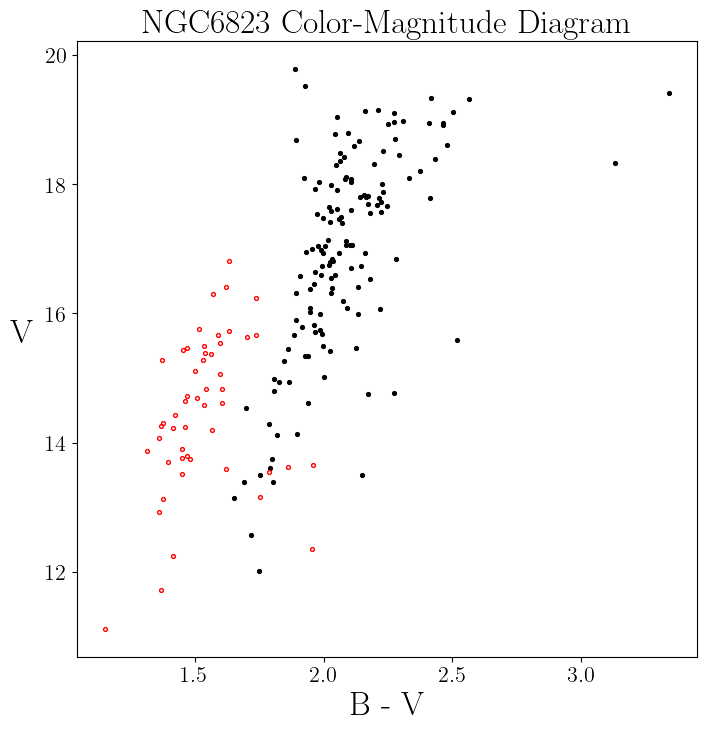

In [1208]:
f, ax = plt.subplots(figsize=(8, 8))

ax.scatter(mags['BV'], mags['V'], color='black', s=7.5)
ax.scatter(mags0['BV'], mags0['V'], edgecolor='red', facecolor=(1, 1, 1, 0), s=7.5)
ax.set_title('NGC6823 Color-Magnitude Diagram', fontsize=24)
ax.set_xlabel('B - V', fontsize=24)
ax.set_ylabel('V', rotation=0, labelpad=17.5, fontsize=24)

# Fun!